### Second test with `pykan` package: Train KAN model on Higgs Boson dataset

In [2]:
import torch
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
df = pd.read_parquet("../data/processed/higgs-challenge.parquet")
df

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_pt_h,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_tau,DER_met_phi_centrality,PRI_tau_pt,PRI_tau_eta,PRI_tau_phi,PRI_lep_pt,PRI_lep_eta,PRI_lep_phi,PRI_met,PRI_met_phi,PRI_jet_num,Weight,Label
0,0.291563,0.312518,-0.537513,0.827433,1.051324,0.250474,0.177739,1.125455,-0.306146,0.852137,0.219323,0.195481,1.831549,-1.356914,-0.664722,-0.151299,0.946720,0.000814,0
1,0.686119,0.867758,-0.229628,1.362732,-0.806740,-0.357485,-0.640228,1.140558,0.103214,1.699803,-1.647922,-0.459562,0.412759,0.030247,0.201519,-1.055246,-0.073277,0.681042,1
2,0.387010,1.278162,-0.958379,1.149398,-0.884327,-0.769381,1.075991,-1.124062,-0.742357,-1.364071,0.015093,0.270970,-0.406328,-1.734980,-0.221721,0.034564,-1.093274,1.660654,1
3,0.948261,-0.814641,-0.714235,1.909810,-0.138723,-0.919983,-0.434281,-1.207968,-0.499518,-1.813616,-1.218544,-0.777730,0.650558,0.838185,-1.102844,-0.478904,-1.093274,1.904263,1
4,-0.564143,-0.923820,0.811589,-1.400143,1.969445,0.929718,-0.978817,0.356038,0.611290,0.316332,0.741182,-0.697966,-0.696172,0.996906,0.078201,1.235231,1.966717,0.025434,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693631,-0.284492,0.143411,1.419955,-1.508773,-0.617670,0.745303,-0.896206,1.080985,0.974501,1.728833,1.041196,-0.285469,1.691431,-1.752065,1.077329,1.255086,0.946720,0.005721,0
693632,-0.396430,-0.386943,0.040837,-0.180342,-0.768926,0.676044,-0.000282,1.127133,-0.477600,-1.421301,0.048122,-0.277096,-1.247834,1.273567,-0.101852,0.851371,0.946720,0.000461,0
693633,-0.234811,-1.044290,-0.689792,0.406000,-0.064074,-0.835291,-0.915986,-0.747325,0.079812,0.885313,0.573835,-0.918243,0.881952,-0.972786,-0.240953,-1.136872,-1.093274,1.189365,1
693634,-0.441792,-0.714351,-0.510322,0.061786,-0.775920,-0.554109,-0.573906,1.137202,-0.134255,-1.027327,-0.838159,-0.578920,-0.961994,0.490981,-0.980924,-0.280356,-0.073277,0.512740,1


For this test, instead of doing as the proposal says and using Cross Validation on the entire dataset, because we are just testing the package, we will do a simple train/test split.

In [5]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Label"])

print(f"Train set size: {len(train_df)}, Test set size: {len(test_df)}")

y_train = train_df["Label"].values
w_train = train_df["Weight"].values
X_test = test_df.drop(columns=["Label", "Weight"]).values
y_test = test_df["Label"].values
w_test = test_df["Weight"].values

dataset = {
    # Encoding label as float, but we'll use binary cross-entropy loss regardless
    "train_input": torch.tensor(train_df.drop(columns=["Label", "Weight"]).values, dtype=torch.float32).to(device),
    "train_label": torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32).to(device),
    "train_weight": torch.tensor(w_train.reshape(-1, 1), dtype=torch.float32).to(device),
    "test_input": torch.tensor(X_test, dtype=torch.float32).to(device),
    "test_label": torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32).to(device),
    "test_weight": torch.tensor(w_test.reshape(-1, 1), dtype=torch.float32).to(device),
}

Train set size: 554908, Test set size: 138728


In [6]:
num_features = dataset["train_input"].shape[1]
print(f"Number of features: {num_features}")

Number of features: 17


### Using KAN


**Important note:** Because the KAN is supposed to learn the probability directly, we need that the last layer of the KAN behaves like a sigmoid function. Thus, we have two options: either we hope that the KAN is capable of learning a sigmoid-like function in its last layer, or we can enforce it by applying a sigmoid activation at the end of the KAN model. The latter is more safe and reasonable, so we will do that. We performed a quick experiment without it, and obviously, there were several issues with the predictions going out of the [0,1] range, which caused errors in the loss calculation. If one looks at the proposed examples in the `pykan` repository, they typically skip this, and let the KAN learn the output directly, but in those examples, the outputs are not probabilities, so it is not an issue.

In [15]:
from kan import KAN


class KANClassifier(KAN):
    def forward(self, x, *args, **kwargs):
        out = super().forward(x, *args, **kwargs)
        return torch.sigmoid(out)

In [ ]:
from src.checkpoints import add_gitignore
from torch import nn


def test_acc():
    return torch.mean(((model_kan(dataset["test_input"]) >= 0.5).int() == dataset["test_label"]).float()).float()


def train_acc():
    train_sample = 1000  # Otherwise this would take too long, in each training step, plus we would have memory issues
    preds = (model_kan(dataset["train_input"][:train_sample]) >= 0.5).int()
    return torch.mean((preds == dataset["train_label"][:train_sample]).float()).float()


loss_fn = nn.BCELoss()

ckpt_path = "../models/pykan-higgs-test/"
add_gitignore(ckpt_path)
model_kan = KANClassifier(width=[num_features, 100, 1], grid=3, k=3, seed=42, ckpt_path=ckpt_path).to(device)
batch_size = 32768
epochs = 20
history = model_kan.fit(
    dataset,
    opt="Adam",
    lr=0.001,
    steps=epochs * len(dataset["train_input"]) // batch_size,  # The trainer samples randomly each iteration, so this
    # param doesn't control epochs directly. But if we want to train this network for roughly the same amount of
    # iterations as the MLP below (10 epochs), we can set it like this. Note that THIS DOES NOT MEAN THAT THE MODEL WILL
    # SEE ALL SAMPLES 10 TIMES, as would be the case in normal epoch-based training.
    lamb=0.001,
    lamb_entropy=5.0,
    update_grid=False,
    loss_fn=loss_fn,
    batch=batch_size,  # Using mini-batches for training (number chosen to fit in GPU memory)
    metrics=(test_acc, train_acc),
)

os.makedirs("../models/pykan-higgs-test/final-model/", exist_ok=True)
model_kan.saveckpt("../models/pykan-higgs-test/final-model")

checkpoint directory created: ../models/pykan-higgs-test/
saving model version 0.0


| train_loss: 6.66e-01 | test_loss: 6.64e-01 | reg: 6.61e+01 | : 100%|█| 338/338 [02:25<00:00,  2.33

saving model version 0.1


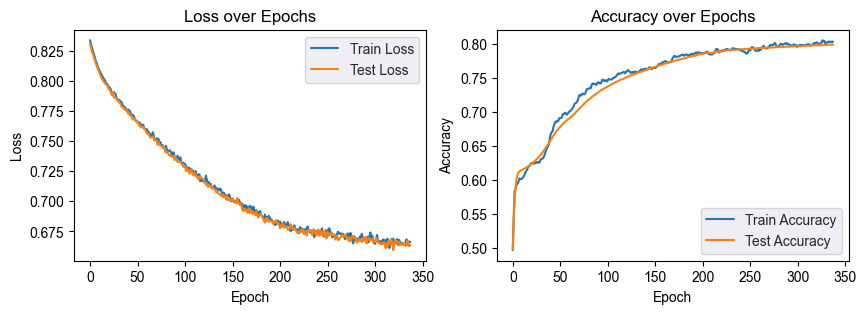

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting training history
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
sns.set_style("darkgrid")

ax[0].plot(history["train_loss"], label="Train Loss")
ax[0].plot(history["test_loss"], label="Test Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("Loss over Epochs")
ax[0].legend()

ax[1].plot(history["train_acc"], label="Train Accuracy")
ax[1].plot(history["test_acc"], label="Test Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Accuracy over Epochs")
ax[1].legend()


plt.show()

In [ ]:
from src.evaluate import report_metrics


def evaluate_model(model, dataset):
    model.eval()
    with torch.no_grad():
        test_proba = model(dataset["test_input"]).cpu().numpy()
        test_preds = (test_proba >= 0.5).astype(int)
    test_labels = dataset["test_label"].cpu().numpy()
    test_weights = dataset["test_weight"].cpu().numpy()

    report_metrics(y_true=test_labels, y_pred=test_preds, y_proba=test_proba, weights=test_weights)


evaluate_model(model_kan, dataset)

#### Visualization

We will now try to visualize the activation functions learned by the KAN model on the Higgs Boson dataset.

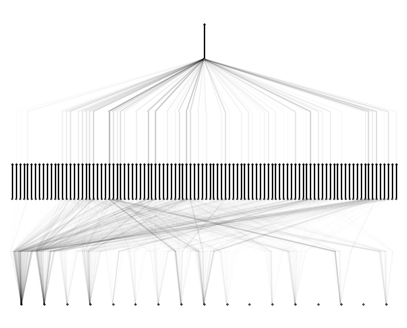

In [19]:
model_kan.plot(folder="../figures/pykan-higgs-test/model-plot/")
add_gitignore("../figures/pykan-higgs-test/model-plot/")

A very cool thing that the `pykan` package provides is a built-in method to prune the KAN model from unnecessary nodes and edges, which are seen in the above plot as very faint lines.

In [20]:
pruned_model_kan = model_kan.prune(node_th=0.01, edge_th=0.01)

saving model version 0.2


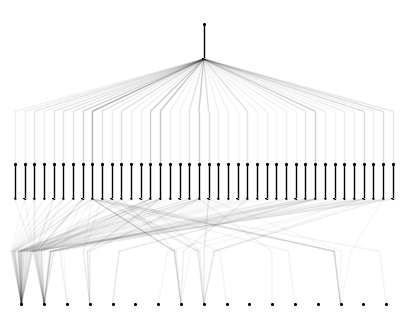

In [21]:
pruned_model_kan.plot(folder="../figures/pykan-higgs-test/pruned-model-plot/")
add_gitignore("../figures/pykan-higgs-test/pruned-model-plot/")

Interestingly, this shows what features are more important for the model, and allows us to see the exact dependencies learned by the KAN.

In [22]:
severely_pruned_model_kan = model_kan.prune(node_th=0.1, edge_th=0.1)

saving model version 0.2


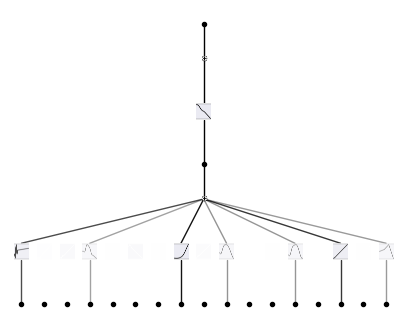

In [23]:
severely_pruned_model_kan.plot(folder="../figures/pykan-higgs-test/severely-pruned-model-plot/")
add_gitignore("../figures/pykan-higgs-test/severely-pruned-model-plot/")

#### Pruning and re-training

Before continuing, let us check how good the pruned models are compared to the original one.

> **Note:** When copying the model, the `pykan` package doesn't properly keep the class type, so it looses the sigmoid activation at the end. Thus, we need to cast it back to our defined `KANClassifier` class.

In [24]:
pruned_model_kan.__class__ = KANClassifier
assert isinstance(pruned_model_kan, KANClassifier)

In [25]:
evaluate_model(pruned_model_kan, dataset)

Accuracy: 0.7664927051496454
Classification report:
               precision    recall  f1-score   support

  background       0.66      0.83      0.73     54075
      signal       0.87      0.73      0.79     84653

    accuracy                           0.77    138728
   macro avg       0.76      0.78      0.76    138728
weighted avg       0.79      0.77      0.77    138728

ROC AUC: 0.861706705319143
AMS: 749.5978393554688


Obviously, having pruned the model after it was trained, the performance has degraded a bit. However, we can re-train the pruned model. We have decreased its size significantly, so it should be faster to train, and if the pruning was done well, it should retain most of the performance.

In [ ]:
def test_acc():
    return torch.mean(((pruned_model_kan(dataset["test_input"]) >= 0.5).int() == dataset["test_label"]).float()).float()


def train_acc():
    train_sample = 1000  # Otherwise this would take too long, in each training step, plus we would have memory issues
    preds = (pruned_model_kan(dataset["train_input"][:train_sample]) >= 0.5).int()
    return torch.mean((preds == dataset["train_label"][:train_sample]).float()).float()


loss_fn = nn.BCELoss()

ckpt_path = "../models/pykan-higgs-test-pruned/"
add_gitignore(ckpt_path)
# Overwrite the checkpoint path to save the pruned model's checkpoints separately
pruned_model_kan.ckpt_path = ckpt_path

batch_size = 32768
epochs = 20
history = pruned_model_kan.fit(
    dataset,
    opt="Adam",
    lr=0.001,
    steps=epochs * len(dataset["train_input"]) // batch_size,  # The trainer samples randomly each iteration, so this
    # param doesn't control epochs directly. But if we want to train this network for roughly the same amount of
    # iterations as the MLP below (10 epochs), we can set it like this. Note that THIS DOES NOT MEAN THAT THE MODEL WILL
    # SEE ALL SAMPLES 10 TIMES, as would be the case in normal epoch-based training.
    lamb=0.001,
    lamb_entropy=5.0,
    update_grid=False,
    loss_fn=loss_fn,
    batch=batch_size,  # Using mini-batches for training (number chosen to fit in GPU memory)
    metrics=(test_acc, train_acc),
)


os.makedirs("../models/pykan-higgs-test-pruned/final-model/", exist_ok=True)
pruned_model_kan.saveckpt("../models/pykan-higgs-test-pruned/final-model/")

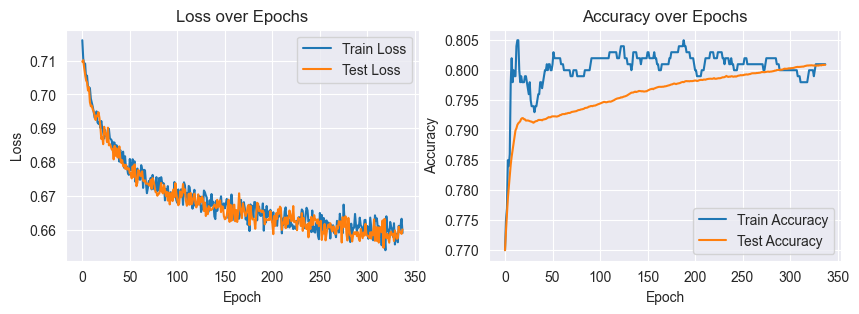

In [29]:
# Plotting training history
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
sns.set_style("darkgrid")

ax[0].plot(history["train_loss"], label="Train Loss")
ax[0].plot(history["test_loss"], label="Test Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("Loss over Epochs")
ax[0].legend()

ax[1].plot(history["train_acc"], label="Train Accuracy")
ax[1].plot(history["test_acc"], label="Test Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Accuracy over Epochs")
ax[1].legend()


plt.show()

In [30]:
evaluate_model(pruned_model_kan, dataset)

Accuracy: 0.8008909520788882
Classification report:
               precision    recall  f1-score   support

  background       0.77      0.71      0.73     54075
      signal       0.82      0.86      0.84     84653

    accuracy                           0.80    138728
   macro avg       0.79      0.78      0.79    138728
weighted avg       0.80      0.80      0.80    138728

ROC AUC: 0.873295516554899
AMS: 784.5444946289062


And, as we expected, we managed to get back all the performance we had before pruning, while having a significantly smaller model.

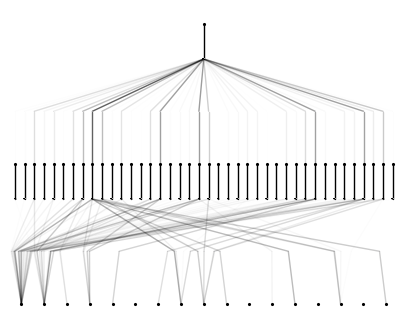

In [31]:
pruned_model_kan.plot(folder="../figures/pykan-higgs-test/pruned-retrained-model-plot/")
add_gitignore("../figures/pykan-higgs-test/pruned-retrained-model-plot/")

#### Final Activation Functions After Pruning and Re-Training

Let us finally visualize the activation functions learned by the pruned and re-trained model. We'll do so by pruning once again, to retain only the most important nodes and edges, and plotting them.

saving model version 0.4


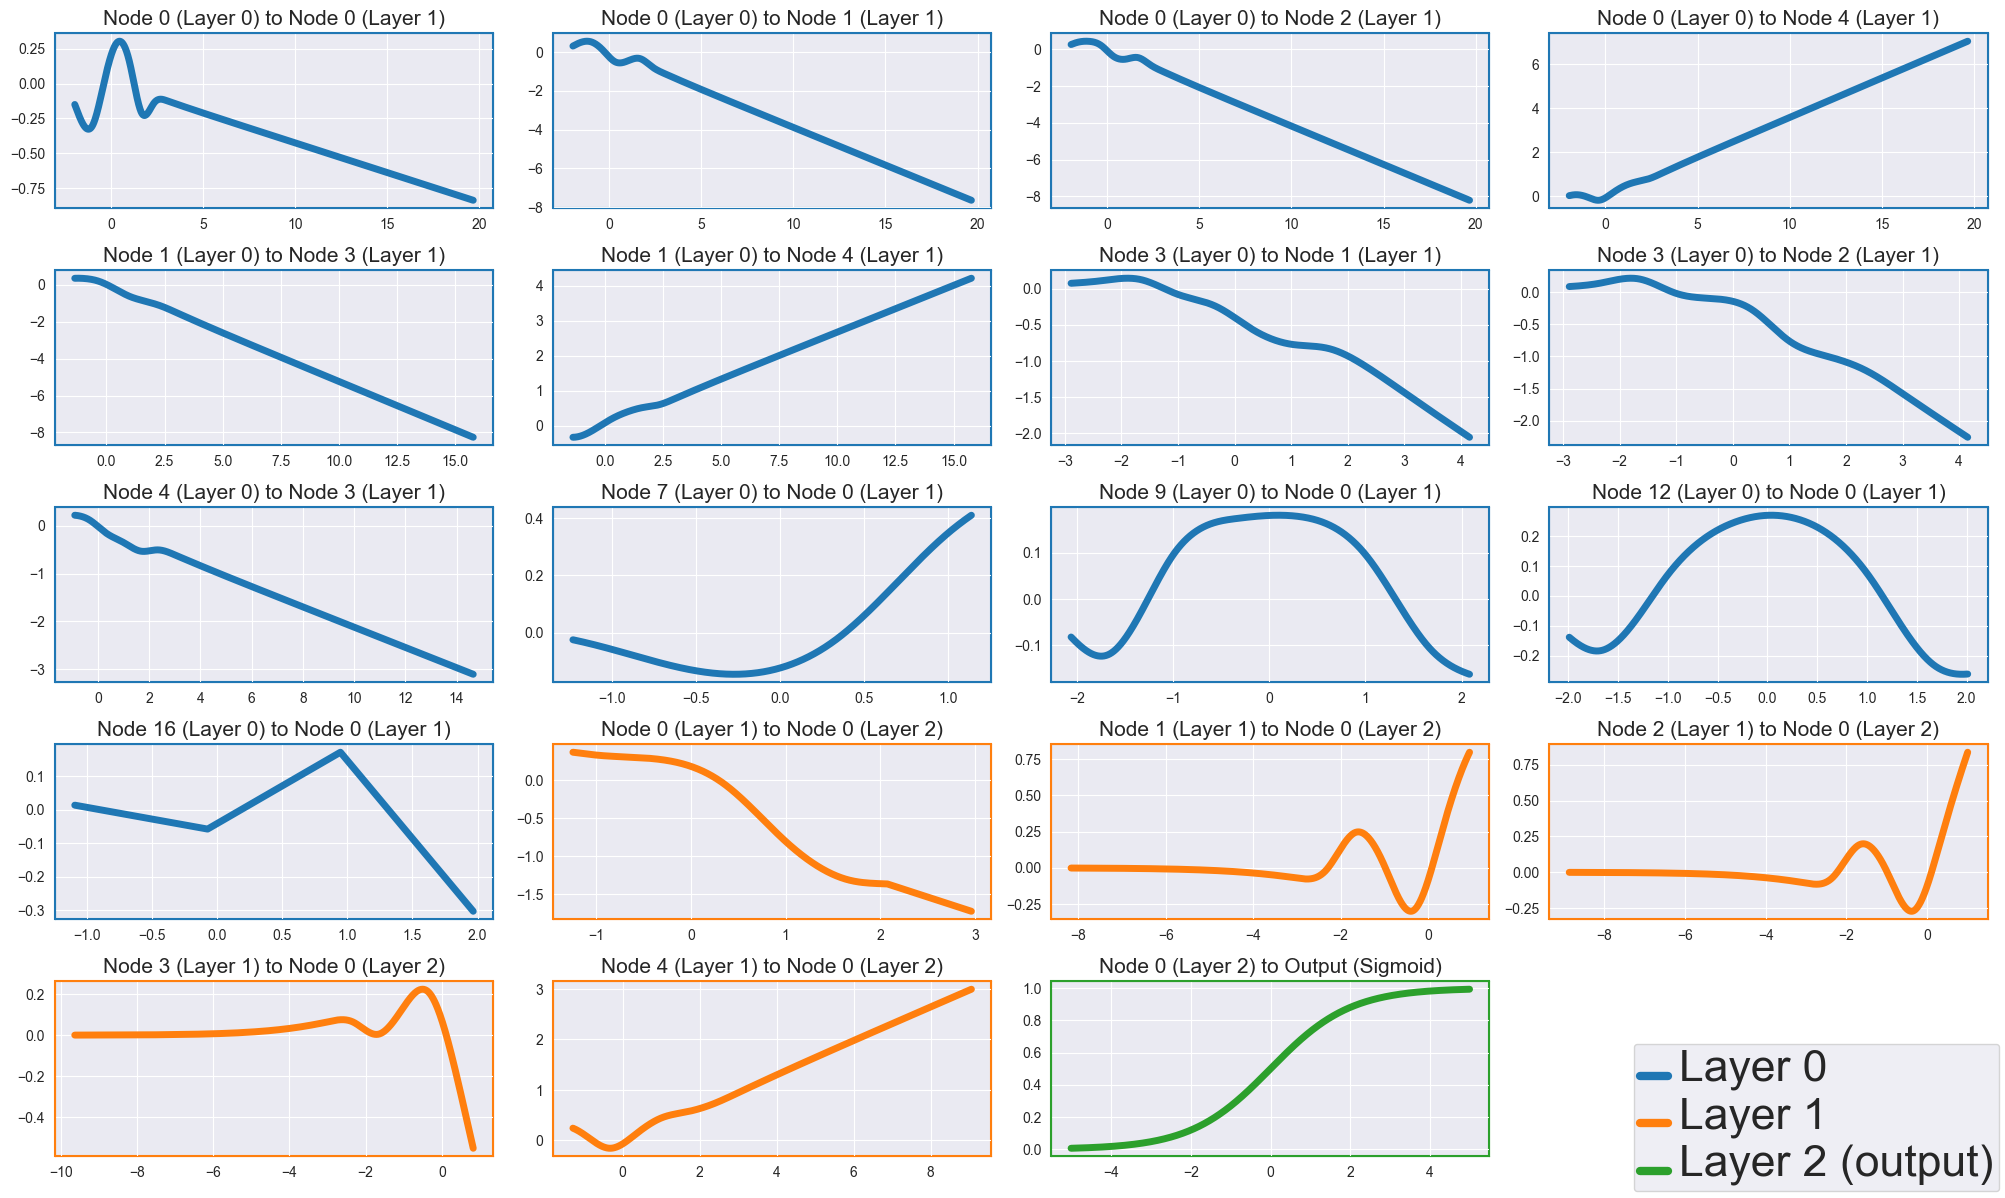

In [80]:
final_pruned_model_kan = pruned_model_kan.prune(node_th=0.1, edge_th=0.1)


mask = []
for l in range(len(final_pruned_model_kan.width) - 1):
    for i in range(final_pruned_model_kan.width_in[l]):
        for j in range(final_pruned_model_kan.width_out[l + 1]):
            symbolic_mask = final_pruned_model_kan.symbolic_fun[l].mask[j][i]
            numeric_mask = final_pruned_model_kan.act_fun[l].mask[i][j]
            if symbolic_mask == 0.0 and numeric_mask > 0.0:
                mask.append((l, i, j))

nrows = 5
ncols = (len(mask) + 1) // nrows + int((len(mask) + 1) % nrows > 0)
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 12))
axes = axes.flatten()
for plot, (l, i, j) in enumerate(mask):
    rank = torch.argsort(final_pruned_model_kan.acts[l][:, i])
    color = sns.color_palette("tab10")[l % 10]
    ax = axes[plot]
    ax.patch.set_edgecolor(color)
    ax.patch.set_linewidth(1.5)
    ax.plot(
        final_pruned_model_kan.acts[l][:, i][rank].cpu().detach().numpy(),
        final_pruned_model_kan.spline_postacts[l][:, j, i][rank].cpu().detach().numpy(),
        color=color,
        lw=5,
    )
    ax.set_title(f"Node {i} (Layer {l}) to Node {j} (Layer {l+1})", fontsize=15)
    ax.spines[:].set_color(color)

distinct_layers = set([l for l, i, j in mask])
out_layer = max(distinct_layers) + 1
# Add a final plot for the sigmoid activation function at the output layer
ax = axes[plot + 1]
color = sns.color_palette("tab10")[out_layer % 10]
ax.patch.set_edgecolor(color)
ax.patch.set_linewidth(1.5)
x = torch.arange(-5, 5, 0.01)
ax.plot(x, torch.sigmoid(x), color=color, lw=5)
ax.set_title(f"Node {0} (Layer {out_layer}) to Output (Sigmoid)", fontsize=15)
ax.spines[:].set_color(color)


# Remove empty subplots
for k in range(plot + 2, len(axes)):
    fig.delaxes(axes[k])

# Add a legend with the colors corresponding to each layer
handles = []
labels = []
for layer in distinct_layers:
    handles.append(plt.Line2D([0], [0], color=sns.color_palette("tab10")[layer % 10], lw=6))
    labels.append(f"Layer {layer}")

handles.append(plt.Line2D([0], [0], color=sns.color_palette("tab10")[out_layer % 10], lw=6))
labels.append(f"Layer {out_layer} (output)")


legend = fig.legend(handles=handles, labels=labels, loc="lower right")
# Set the legend font size larger
for text in legend.get_texts():
    text.set_fontsize(32)
fig.tight_layout()

### Now let's repeat the experiment using an MLP

Because I want to see the history and have finer-grained control over the training process, I will implement the MLP using pure PyTorch.

In [8]:
from typing import List
from torch import nn


class MLPClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: List[int], output_dim: int):
        super(MLPClassifier, self).__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())  # Using ReLU activation for hidden layers
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, output_dim))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [9]:
model_mlp = MLPClassifier(input_dim=num_features, hidden_dims=[100], output_dim=1).to(device)

In [12]:
from tqdm.auto import tqdm


def test_acc():
    return torch.mean(((model_mlp(dataset["test_input"]) >= 0.5).int() == dataset["test_label"]).float()).float()


def train_acc():
    train_sample = 1000  # Otherwise this would take too long, in each training step, plus we would have memory issues
    preds = (model_mlp(dataset["train_input"][:train_sample]) >= 0.5).int()
    return torch.mean((preds == dataset["train_label"][:train_sample]).float()).float()


loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=0.001)
batch_size = 32768
epochs = 20
history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
bar = tqdm(range(epochs), desc="Training MLP")
for epoch in bar:
    model_mlp.train()
    permutation = torch.randperm(dataset["train_input"].size()[0])
    for i in range(0, dataset["train_input"].size()[0], batch_size):
        indices = permutation[i : i + batch_size]
        batch_x, batch_y = dataset["train_input"][indices], dataset["train_label"][indices]

        optimizer.zero_grad()
        outputs = model_mlp(batch_x)
        loss = loss_fn(outputs, batch_y)
        loss.backward()
        optimizer.step()

    model_mlp.eval()
    with torch.no_grad():
        train_outputs = model_mlp(dataset["train_input"])
        test_outputs = model_mlp(dataset["test_input"])
        train_loss = loss_fn(train_outputs, dataset["train_label"]).item()
        test_loss = loss_fn(test_outputs, dataset["test_label"]).item()

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_acc"].append(train_acc().item())
    history["test_acc"].append(test_acc().item())

    bar.set_postfix(
        train_loss=train_loss, test_loss=test_loss, train_acc=history["train_acc"][-1], test_acc=history["test_acc"][-1]
    )

Training MLP:   0%|          | 0/20 [00:00<?, ?it/s]

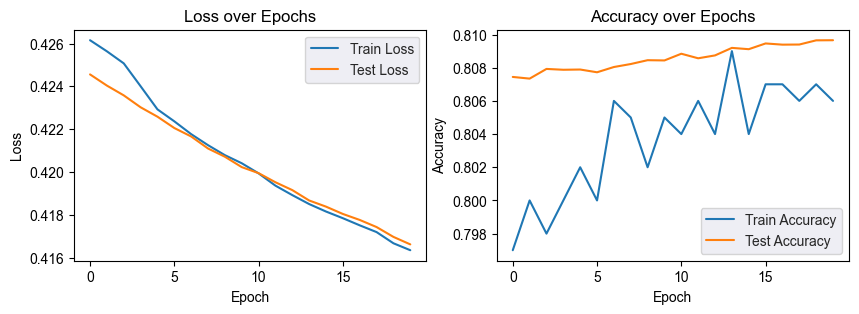

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting training history
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
sns.set_style("darkgrid")

ax[0].plot(history["train_loss"], label="Train Loss")
ax[0].plot(history["test_loss"], label="Test Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("Loss over Epochs")
ax[0].legend()

ax[1].plot(history["train_acc"], label="Train Accuracy")
ax[1].plot(history["test_acc"], label="Test Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Accuracy over Epochs")
ax[1].legend()


plt.show()

In [19]:
test_proba = model_mlp(dataset["test_input"]).reshape(-1, 1).cpu().detach().numpy()
test_preds = (test_proba >= 0.5).astype(int)
test_labels = dataset["test_label"].cpu().numpy()
test_weights = dataset["test_weight"].cpu().numpy()


report_metrics(y_true=test_labels, y_pred=test_preds, y_proba=test_proba, weights=test_weights)

Accuracy: 0.8096563058647137
Classification report:
               precision    recall  f1-score   support

  background       0.77      0.73      0.75     54075
      signal       0.83      0.86      0.85     84653

    accuracy                           0.81    138728
   macro avg       0.80      0.79      0.80    138728
weighted avg       0.81      0.81      0.81    138728

ROC AUC: 0.8847214812744109
AMS: 791.1005859375
